# Imports

In [59]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

# EDA

In [2]:
df = pd.read_csv("telecom_churn.csv")

In [27]:
df.shape

(3333, 11)

In [55]:
df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='object')

In [68]:
df.columns = ['Churn', 'time_last_transaction', 'time_last_login', 'price', 'quantity',
       'store_type', 'tva_precentage', 'tva_type', 'has_wallet', 'balance',
       'operating_hours']

In [69]:
df.columns

Index(['Churn', 'time_last_transaction', 'time_last_login', 'price',
       'quantity', 'store_type', 'tva_precentage', 'tva_type', 'has_wallet',
       'balance', 'operating_hours'],
      dtype='object')

In [57]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

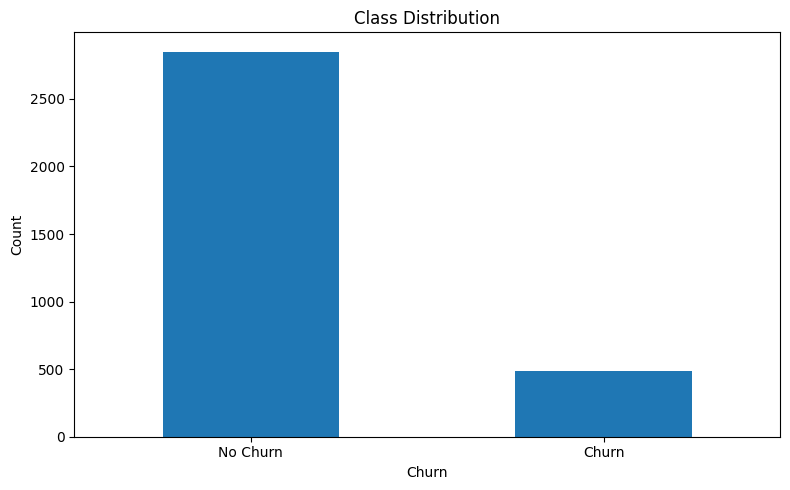

# Helper functions

In [ ]:
def print_report(y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    print("Model Evaluation")
    print("----------------")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

In [53]:
def plot_cofusion_matrix(y_test, y_pred):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [61]:
def plot_roc_curve(y_test, y_prob):
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
    plt.title("ROC Curve")
    plt.tight_layout()
    plt.show()

In [63]:
def plot_precision_recall_curve(y_test,y_prob):
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax)
    plt.title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

In [62]:
def plot_prob_distribution(y_test, y_prob):
    plt.figure(figsize=(8, 5))
    plt.hist(y_prob[y_test == 0], bins=20, alpha=0.7, label="Predicted No Churn")
    plt.hist(y_prob[y_test == 1], bins=20, alpha=0.7, label="Predicted Churn")
    plt.xlabel("Predicted Churn Probability")
    plt.ylabel("Count")
    plt.title("Predicted Probability Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [64]:
def plot_score_distribution(loyalty_score):
    plt.figure(figsize=(8, 5))
    plt.hist(loyalty_score, bins=20, alpha=0.8)
    plt.xlabel("Loyalty Score")
    plt.ylabel("Count")
    plt.title("Loyalty Score Distribution")
    plt.tight_layout()
    plt.show()

In [65]:
def plot_learning_curve(model, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=None
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation Score")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.title("Learning Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [26]:
def cashback(churn_prob, c_min=1, c_max=10):
    loyalty = 1 - churn_prob
    return c_min + (c_max - c_min) * loyalty

In [49]:
def cashback(loyalty, spending, c_min=1, c_max=10, alpha=0.7):
    score = alpha * loyalty + (1 - alpha) * spending
    return c_min + (c_max - c_min) * (score ** 2)

# EDA

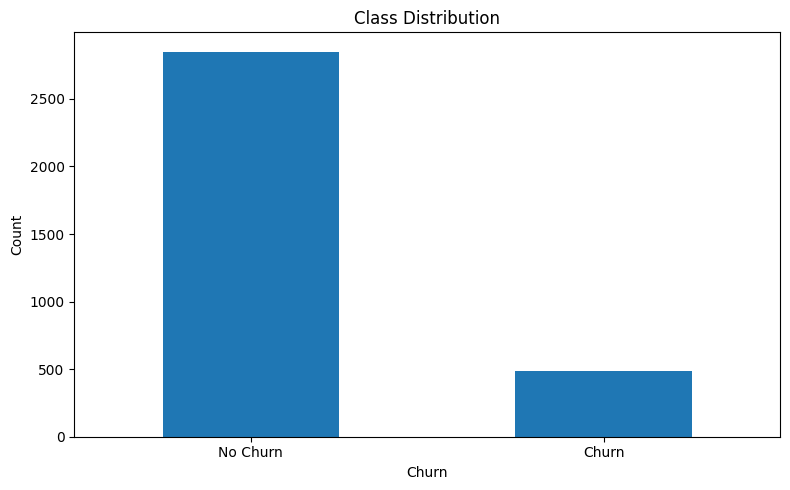

In [70]:
plt.figure(figsize=(8, 5))
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Churn", "Churn"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [85]:
df.head()

,Churn,time_last_transaction,tva_type,has_wallet,quantity,store_type,price,time_last_login,balance,operating_hours,tva_precentage
0,0,128,1,1,4.0,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,5.0,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,1.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,1.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,1.0,3,166.7,113,41.0,7.42,10.1


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Churn                  3333 non-null   int64  
 1   time_last_transaction  3333 non-null   int64  
 2   tva_type               3333 non-null   int64  
 3   has_wallet             3333 non-null   int64  
 4   quantity               3333 non-null   float64
 5   store_type             3333 non-null   int64  
 6   price                  3333 non-null   float64
 7   time_last_login        3333 non-null   int64  
 8   balance                3333 non-null   float64
 9   operating_hours        3333 non-null   float64
 10  tva_precentage         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [89]:
df.describe()

,Churn,time_last_transaction,tva_type,has_wallet,quantity,store_type,price,time_last_login,balance,operating_hours,tva_precentage
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,1.767177,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.309460,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,1.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,1.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,3.000000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,6.000000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [95]:
def plot_hist(data, xlabel, title):
    plt.hist(data, bins=25)
    plt.xlabel(xlabel)
    plt.ylabel('value')
    plt.title(title)
    plt.savefig('./eda/' + title +'.png')
    plt.tight_layout

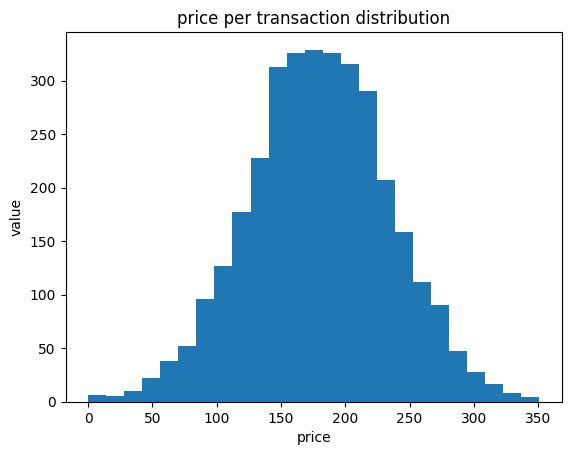

In [96]:
plot_hist(df['price'], 'price', 'price per transaction distribution')

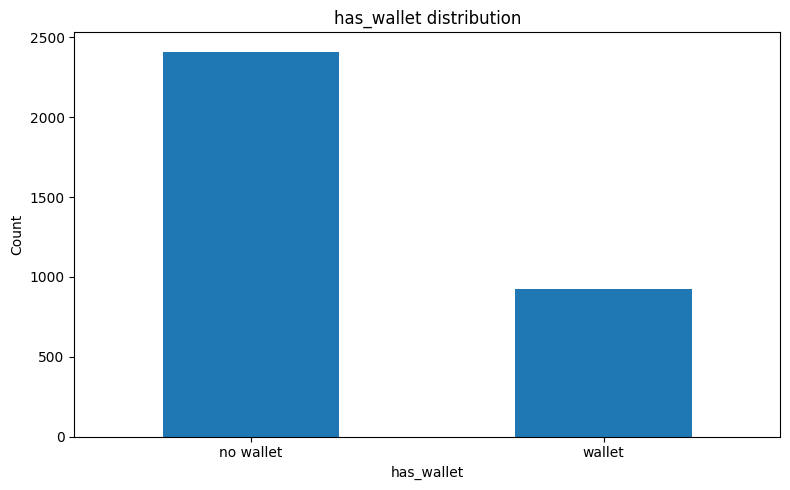

In [ ]:
plt.figure(figsize=(8, 5))
df['has_wallet'].value_counts().sort_index().plot(kind="bar", xlabel='')
plt.xticks([0, 1], ["no wallet", "wallet"], rotation=0)
plt.title("has_wallet distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()